# 15. Сравнение ROC-кривых всех участников

Сравнение ROC-кривых по **сохранённым скорам** (без перепрогона моделей).

**Источники скоров:**
- **AutoIntent KNN**: `runs/eval_scores_autointent_classic-light_e5large_*.jsonl` (поле `score_jb`)
- **AutoIntent Linear**: `runs/eval_scores_autointent_classic-light_e5large_qp_classify_if_this_request_is_a_ja_*.jsonl` — прогон с query_prompt, где оптимизация выбрала Linear scorer вместо KNN (см. nb10)
- **AutoML E5** (AutoGluon, H2O, LAMA wrappers): `results/metrics.json`, поле `extra.scores`
- **Простые головы E5** (LightGBM, LogReg из nb12/13): `results/diagnostics/nb13_eval_probas.npz`
- **y_true**: из `data/processed/wildjailbreak_eval_binary.jsonl` (2210 примеров)

**Примечание о терминологии:**
- **AutoIntent KNN** — AutoIntent с KNN scorer (без query_prompt)
- **AutoIntent Linear** — AutoIntent с Linear scorer (выбран из-за query_prompt бага, см. nb10)
- **E5_LGBM, E5_LINEAR** — простые классификаторы (LightGBM, LogisticRegression) из nb12/13, НЕ AutoIntent

**Структура:**
- Этап 0: Диагностика (проверка данных)
- Этап 1: ROC-кривые (усреднённые по сидам)
- Этап 2: Trade-off recall vs ORR
- Этап 3: Decision rule на границе + абсолютные метрики

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, precision_score, recall_score
from scipy import interpolate
import warnings
warnings.filterwarnings('ignore')

# Пути
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
RUNS_DIR = BASE_DIR / "runs"
DIAG_DIR = RESULTS_DIR / "diagnostics"

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")
print(f"RESULTS_DIR exists: {RESULTS_DIR.exists()}")
print(f"RUNS_DIR exists: {RUNS_DIR.exists()}")

BASE_DIR: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection
DATA_DIR exists: True
RESULTS_DIR exists: True
RUNS_DIR exists: True


---
# ЭТАП 0: ДИАГНОСТИКА

Проверяем пригодность данных ДО построения графиков.

## 0.1 Загрузка y_true из eval_binary

In [2]:
# Загрузка eval_binary (ground truth)
eval_binary_path = DATA_DIR / "wildjailbreak_eval_binary.jsonl"

eval_binary = []
with open(eval_binary_path) as f:
    for line in f:
        eval_binary.append(json.loads(line))

# Извлекаем y_true и тексты для проверки выравнивания
y_true = np.array([1 if r["binary_label"] == "jailbreak" else 0 for r in eval_binary])
eval_texts = [r["prompt"] for r in eval_binary]
eval_data_types = np.array([r["data_type"] for r in eval_binary])

print(f"eval_binary: {len(eval_binary)} примеров")
print(f"y_true shape: {y_true.shape}")
print(f"Распределение y_true: safe={sum(y_true==0)}, jailbreak={sum(y_true==1)}")
print(f"data_types: {np.unique(eval_data_types, return_counts=True)}")

eval_binary: 2210 примеров
y_true shape: (2210,)
Распределение y_true: safe=210, jailbreak=2000
data_types: (array(['adversarial_benign', 'adversarial_harmful'], dtype='<U19'), array([ 210, 2000]))


## 0.2 Загрузка скоров: AutoIntent

In [3]:
def load_autointent_scores(mode: str, seed: int, with_qp: bool = False) -> dict | None:
    """
    Загружает AutoIntent eval_scores из jsonl файла.
    
    with_qp=False: AutoIntent KNN (без query_prompt)
    with_qp=True:  AutoIntent Linear (с query_prompt → Linear scorer выбран)
    
    Возвращает dict с 'scores', 'texts', 'y_true_file' или None если файл не найден.
    """
    if with_qp:
        pattern = f"eval_scores_autointent_classic-light_e5large_qp_classify_if_this_request_is_a_ja_{mode}_seed{seed}.jsonl"
    else:
        pattern = f"eval_scores_autointent_classic-light_e5large_{mode}_seed{seed}.jsonl"
    
    fpath = RUNS_DIR / pattern
    if not fpath.exists():
        return None
    
    records = []
    with open(fpath) as f:
        for line in f:
            records.append(json.loads(line))
    
    scores = np.array([r["score_jb"] for r in records])
    texts = [r["text"] for r in records]
    y_true_file = np.array([r["y_true"] for r in records])
    
    return {
        "scores": scores,
        "texts": texts,
        "y_true_file": y_true_file,
        "path": str(fpath),
    }

# Тест загрузки обоих вариантов
print("AutoIntent KNN (без query_prompt):")
test_knn = load_autointent_scores("full", 42, with_qp=False)
if test_knn:
    print(f"  full seed42: {len(test_knn['scores'])} скоров, диапазон [{test_knn['scores'].min():.4f}, {test_knn['scores'].max():.4f}]")
    print(f"  уникальных значений: {len(np.unique(test_knn['scores']))} (дискретные → KNN)")
else:
    print("  full seed42: НЕ НАЙДЕН")

print("\nAutoIntent Linear (с query_prompt):")
test_linear = load_autointent_scores("full", 42, with_qp=True)
if test_linear:
    print(f"  full seed42: {len(test_linear['scores'])} скоров, диапазон [{test_linear['scores'].min():.4f}, {test_linear['scores'].max():.4f}]")
    print(f"  уникальных значений: {len(np.unique(test_linear['scores']))} (непрерывные → Linear)")
else:
    print("  full seed42: НЕ НАЙДЕН")

AutoIntent KNN (без query_prompt):
  full seed42: 2210 скоров, диапазон [0.0000, 1.0000]
  уникальных значений: 11 (дискретные → KNN)

AutoIntent Linear (с query_prompt):
  full seed42: 2210 скоров, диапазон [0.0016, 1.0000]
  уникальных значений: 2210 (непрерывные → Linear)


## 0.3 Загрузка скоров: AutoML E5 (metrics.json)

In [4]:
# Загрузка metrics.json
metrics_path = RESULTS_DIR / "metrics.json"
with open(metrics_path) as f:
    all_metrics = json.load(f)

def load_automl_e5_scores(model_name: str, mode: str, seed: int) -> dict | None:
    """
    Загружает AutoML E5 скоры из metrics.json.
    model_name: 'autogluon', 'h2o', 'lama'
    Возвращает dict с 'scores' или None если не найден.
    """
    for r in all_metrics:
        if (r.get("model_name") == model_name and 
            r.get("mode") == mode and 
            r.get("seed") == seed):
            scores = r.get("extra", {}).get("scores")
            if scores:
                return {
                    "scores": np.array(scores),
                    "source": "metrics.json",
                }
    return None

# Тест
for model in ["autogluon", "h2o", "lama"]:
    test_e5 = load_automl_e5_scores(model, "10shot", 42)
    if test_e5:
        print(f"{model} 10shot seed42: {len(test_e5['scores'])} скоров, диапазон [{test_e5['scores'].min():.4f}, {test_e5['scores'].max():.4f}]")
    else:
        print(f"{model} 10shot seed42: НЕ НАЙДЕН")

autogluon 10shot seed42: 2210 скоров, диапазон [0.2933, 0.6867]
h2o 10shot seed42: 2210 скоров, диапазон [0.1383, 0.9099]
lama 10shot seed42: 2210 скоров, диапазон [0.4970, 0.5039]


## 0.4 Загрузка скоров: Простые головы E5 (nb13_eval_probas.npz)

Это LightGBM и Linear (LogisticRegression), обученные напрямую на E5-эмбеддингах в nb12/13.
НЕ AutoIntent — это отдельные baseline-модели для сравнения.

In [5]:
# Загрузка nb13 probas
nb13_path = DIAG_DIR / "nb13_eval_probas.npz"
nb13_data = None
nb13_keys = []

if nb13_path.exists():
    nb13_data = np.load(nb13_path)
    nb13_keys = list(nb13_data.keys())
    print(f"nb13_eval_probas.npz загружен. Ключи: {nb13_keys}")
    for k in nb13_keys:
        arr = nb13_data[k]
        print(f"  {k}: shape={arr.shape}, диапазон=[{arr.min():.4f}, {arr.max():.4f}]")
else:
    print(f"ПРЕДУПРЕЖДЕНИЕ: {nb13_path} НЕ НАЙДЕН")

# KNN нет в этом файле
print("\nПримечание: KNN probas НЕТ в nb13_eval_probas.npz (только lgbm, linear)")

nb13_eval_probas.npz загружен. Ключи: ['lgbm_42', 'lgbm_123', 'lgbm_456', 'linear_42', 'linear_123', 'linear_456']
  lgbm_42: shape=(2210,), диапазон=[0.0000, 1.0000]
  lgbm_123: shape=(2210,), диапазон=[0.0001, 1.0000]
  lgbm_456: shape=(2210,), диапазон=[0.0000, 1.0000]
  linear_42: shape=(2210,), диапазон=[0.0060, 0.9997]
  linear_123: shape=(2210,), диапазон=[0.0087, 0.9997]
  linear_456: shape=(2210,), диапазон=[0.0083, 0.9997]

Примечание: KNN probas НЕТ в nb13_eval_probas.npz (только lgbm, linear)


## 0.5 Проверка порядка примеров (КРИТИЧНО)

Сверяем порядок скоров с порядком y_true в eval_binary по тексту.

In [6]:
def check_text_alignment(source_name: str, source_texts: list, anchor_indices: list = [0, 1, 2, 100, 500]):
    """
    Проверяет совпадение текстов источника с eval_binary по индексам.
    Возвращает (is_aligned, mismatches).
    """
    mismatches = []
    for idx in anchor_indices:
        if idx >= len(source_texts) or idx >= len(eval_texts):
            continue
        src_text = source_texts[idx][:100]
        eval_text = eval_texts[idx][:100]
        if src_text != eval_text:
            mismatches.append((idx, src_text[:50], eval_text[:50]))
    
    is_aligned = len(mismatches) == 0
    return is_aligned, mismatches

# Проверка AutoIntent KNN
print("=" * 60)
print("ПРОВЕРКА ВЫРАВНИВАНИЯ: AutoIntent KNN")
print("=" * 60)
ai_knn = load_autointent_scores("full", 42, with_qp=False)
if ai_knn:
    is_aligned, mismatches = check_text_alignment("AutoIntent KNN", ai_knn["texts"])
    if is_aligned:
        print("✓ AutoIntent KNN тексты ВЫРОВНЕНЫ с eval_binary")
    else:
        print("✗ AutoIntent KNN тексты НЕ ВЫРОВНЕНЫ")
    y_true_match = np.array_equal(ai_knn["y_true_file"], y_true)
    print(f"  y_true из файла совпадает с eval_binary: {y_true_match}")

# Проверка AutoIntent Linear
print("\n" + "=" * 60)
print("ПРОВЕРКА ВЫРАВНИВАНИЯ: AutoIntent Linear")
print("=" * 60)
ai_linear = load_autointent_scores("full", 42, with_qp=True)
if ai_linear:
    is_aligned, mismatches = check_text_alignment("AutoIntent Linear", ai_linear["texts"])
    if is_aligned:
        print("✓ AutoIntent Linear тексты ВЫРОВНЕНЫ с eval_binary")
    else:
        print("✗ AutoIntent Linear тексты НЕ ВЫРОВНЕНЫ")
    y_true_match = np.array_equal(ai_linear["y_true_file"], y_true)
    print(f"  y_true из файла совпадает с eval_binary: {y_true_match}")

print("\n" + "=" * 60)
print("ДОПУЩЕНИЕ: AutoML E5 / nb13")
print("=" * 60)
print("AutoML E5 (metrics.json) и nb13_eval_probas.npz не хранят тексты.")
print("ДОПУЩЕНИЕ: Скоры в том же порядке, что и eval_binary (индекс 0..2209).")

ПРОВЕРКА ВЫРАВНИВАНИЯ: AutoIntent KNN
✓ AutoIntent KNN тексты ВЫРОВНЕНЫ с eval_binary
  y_true из файла совпадает с eval_binary: True

ПРОВЕРКА ВЫРАВНИВАНИЯ: AutoIntent Linear
✓ AutoIntent Linear тексты ВЫРОВНЕНЫ с eval_binary
  y_true из файла совпадает с eval_binary: True

ДОПУЩЕНИЕ: AutoML E5 / nb13
AutoML E5 (metrics.json) и nb13_eval_probas.npz не хранят тексты.
ДОПУЩЕНИЕ: Скоры в том же порядке, что и eval_binary (индекс 0..2209).


## 0.5.1 Косвенная проверка порядка скоров AutoML E5

AutoML E5 (metrics.json) не хранит тексты. Проверяем порядок косвенно:
применяем порог >=0.5 к `extra.scores`, пересчитываем F1/Recall/ORR и сравниваем
с метриками, записанными в том же record metrics.json.

In [7]:
# Определяем SEEDS здесь, чтобы использовать в проверках
SEEDS = [42, 123, 456]

def validate_automl_e5_scores_order():
    """
    Косвенная проверка порядка скоров AutoML E5.
    Применяем порог >=0.5 к extra.scores, пересчитываем метрики и сравниваем
    с записанными в metrics.json.
    """
    results = []
    TOLERANCE = 1e-3  # допустимое расхождение
    
    for record in all_metrics:
        model_name = record.get("model_name")
        mode = record.get("mode")
        seed = record.get("seed")
        
        # Только AutoML E5 wrappers (autogluon, h2o, lama)
        if model_name not in ["autogluon", "h2o", "lama"]:
            continue
        
        scores = record.get("extra", {}).get("scores")
        if not scores:
            continue
        
        scores = np.array(scores)
        
        # Записанные метрики
        f1_stored = record.get("f1")
        recall_stored = record.get("recall")
        orr_stored = record.get("over_refusal_rate")
        
        if f1_stored is None or recall_stored is None or orr_stored is None:
            continue
        
        # Пересчёт метрик с порогом >=0.5 (Правило B, которое используют AutoML wrappers)
        preds = (scores >= 0.5).astype(int)
        
        f1_calc = f1_score(y_true, preds, pos_label=1, zero_division=0)
        recall_calc = recall_score(y_true, preds, pos_label=1, zero_division=0)
        
        # ORR = FPR на safe
        fp = ((preds == 1) & (y_true == 0)).sum()
        tn = ((preds == 0) & (y_true == 0)).sum()
        orr_calc = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        # Сравнение
        f1_match = abs(f1_stored - f1_calc) < TOLERANCE
        recall_match = abs(recall_stored - recall_calc) < TOLERANCE
        orr_match = abs(orr_stored - orr_calc) < TOLERANCE
        all_match = f1_match and recall_match and orr_match
        
        results.append({
            "model": model_name,
            "mode": mode,
            "seed": seed,
            "F1_stored": f1_stored,
            "F1_calc": f1_calc,
            "F1_match": f1_match,
            "Recall_stored": recall_stored,
            "Recall_calc": recall_calc,
            "Recall_match": recall_match,
            "ORR_stored": orr_stored,
            "ORR_calc": orr_calc,
            "ORR_match": orr_match,
            "ALL_MATCH": all_match,
        })
    
    return pd.DataFrame(results)

print("=" * 80)
print("КОСВЕННАЯ ПРОВЕРКА ПОРЯДКА СКОРОВ: AutoML E5")
print("=" * 80)
print("Метод: применить >=0.5 к extra.scores, сравнить F1/Recall/ORR с записанными")
print()

validation_df = validate_automl_e5_scores_order()

if len(validation_df) == 0:
    print("⚠️  Нет данных для проверки AutoML E5")
else:
    n_checked = len(validation_df)
    n_passed = validation_df["ALL_MATCH"].sum()
    n_failed = n_checked - n_passed
    
    print(f"Проверено: {n_checked} записей")
    print(f"Совпадают: {n_passed}")
    print(f"Расходятся: {n_failed}")
    print()
    
    if n_failed == 0:
        print("✓ ВСЕ ПРОВЕРКИ ПРОЙДЕНЫ: порядок скоров AutoML E5 корректен")
    else:
        print("⚠️  ОБНАРУЖЕНЫ РАСХОЖДЕНИЯ:")
        failed_df = validation_df[~validation_df["ALL_MATCH"]]
        display(failed_df[["model", "mode", "seed", "F1_stored", "F1_calc", 
                           "Recall_stored", "Recall_calc", "ORR_stored", "ORR_calc"]])
        print("\n⛔ ПРЕДУПРЕЖДЕНИЕ: Порядок скоров может быть нарушен!")
    
    # Сводная таблица
    print("\nСводка по моделям:")
    summary = validation_df.groupby("model")["ALL_MATCH"].agg(["sum", "count"])
    summary.columns = ["passed", "total"]
    summary["status"] = summary.apply(lambda r: "✓" if r["passed"] == r["total"] else "✗", axis=1)
    display(summary)

# ============================================================
# КОСВЕННАЯ ПРОВЕРКА nb13 через ROC-AUC
# ============================================================
print()
print("=" * 80)
print("КОСВЕННАЯ ПРОВЕРКА ПОРЯДКА СКОРОВ: nb13 (E5_LGBM, E5_LINEAR)")
print("=" * 80)
print("Метод: сравнить ROC-AUC с известными значениями из nb13")
print("  (nb13 ROC: lgbm=0.8190, linear=0.7833)")
print()

NB13_EXPECTED_ROC = {"lgbm": 0.8190, "linear": 0.7833}
TOLERANCE_ROC = 0.001

nb13_validation = []
if nb13_data is not None:
    for head in ["lgbm", "linear"]:
        expected_roc = NB13_EXPECTED_ROC[head]
        rocs_by_seed = []
        for seed in SEEDS:
            key = f"{head}_{seed}"
            if key in nb13_keys:
                scores = nb13_data[key]
                roc = roc_auc_score(y_true, scores)
                rocs_by_seed.append(roc)
        
        if rocs_by_seed:
            mean_roc = np.mean(rocs_by_seed)
            match = abs(mean_roc - expected_roc) < TOLERANCE_ROC
            nb13_validation.append({
                "head": head,
                "expected_roc": expected_roc,
                "computed_roc": mean_roc,
                "match": match,
            })
            status = "✓" if match else "✗"
            print(f"  {status} E5_{head.upper()}: ROC ожидаемый={expected_roc:.4f}, вычисленный={mean_roc:.4f}")

if all(v["match"] for v in nb13_validation):
    print("\n✓ ROC-AUC совпадает → порядок скоров nb13 корректен")
else:
    print("\n⚠️  ROC-AUC расходится → возможно нарушение порядка скоров nb13")

КОСВЕННАЯ ПРОВЕРКА ПОРЯДКА СКОРОВ: AutoML E5
Метод: применить >=0.5 к extra.scores, сравнить F1/Recall/ORR с записанными

Проверено: 33 записей
Совпадают: 33
Расходятся: 0

✓ ВСЕ ПРОВЕРКИ ПРОЙДЕНЫ: порядок скоров AutoML E5 корректен

Сводка по моделям:


,passed,total,status
model,,,
autogluon,12,12,✓
h2o,9,9,✓
lama,12,12,✓



КОСВЕННАЯ ПРОВЕРКА ПОРЯДКА СКОРОВ: nb13 (E5_LGBM, E5_LINEAR)
Метод: сравнить ROC-AUC с известными значениями из nb13
  (nb13 ROC: lgbm=0.8190, linear=0.7833)

  ✓ E5_LGBM: ROC ожидаемый=0.8190, вычисленный=0.8190
  ✓ E5_LINEAR: ROC ожидаемый=0.7833, вычисленный=0.7833

✓ ROC-AUC совпадает → порядок скоров nb13 корректен


## 0.6 Таблица доступности скоров

In [8]:
# SEEDS уже определён в cell-14
MODES_FEWSHOT = ["10shot", "20shot", "50shot"]
MODES_ALL = ["full"] + MODES_FEWSHOT

# Строим таблицу доступности
availability = defaultdict(dict)

# AutoIntent KNN (без query_prompt)
for mode in MODES_ALL:
    for seed in SEEDS:
        data = load_autointent_scores(mode, seed, with_qp=False)
        key = f"{mode}_seed{seed}"
        availability["AutoIntent_KNN"][key] = len(data["scores"]) if data else None

# AutoIntent Linear (с query_prompt → Linear scorer выбран)
for mode in MODES_ALL:
    for seed in SEEDS:
        data = load_autointent_scores(mode, seed, with_qp=True)
        key = f"{mode}_seed{seed}"
        availability["AutoIntent_Linear"][key] = len(data["scores"]) if data else None

# AutoML E5
for model in ["autogluon", "h2o", "lama"]:
    display_name = f"AutoML_{model.upper()}"
    for mode in MODES_ALL:
        for seed in SEEDS:
            data = load_automl_e5_scores(model, mode, seed)
            key = f"{mode}_seed{seed}"
            availability[display_name][key] = len(data["scores"]) if data else None

# nb13 heads (только full — обучены на полных эмбеддингах)
if nb13_data is not None:
    for head in ["lgbm", "linear"]:
        display_name = f"E5_{head.upper()}"
        for seed in SEEDS:
            key_npz = f"{head}_{seed}"
            if key_npz in nb13_keys:
                arr = nb13_data[key_npz]
                key = f"full_seed{seed}"
                availability[display_name][key] = len(arr)

# Выводим как DataFrame
avail_df = pd.DataFrame(availability).T
col_order = [f"{m}_seed{s}" for m in MODES_ALL for s in SEEDS]
avail_df = avail_df[[c for c in col_order if c in avail_df.columns]]

print("ТАБЛИЦА ДОСТУПНОСТИ (количество скоров, None = отсутствует):")
print("Ожидается: 2210 для всех")
print()
display(avail_df.fillna("-"))

ТАБЛИЦА ДОСТУПНОСТИ (количество скоров, None = отсутствует):
Ожидается: 2210 для всех



,full_seed42,full_seed123,full_seed456,10shot_seed42,10shot_seed123,10shot_seed456,20shot_seed42,20shot_seed123,20shot_seed456,50shot_seed42,50shot_seed123,50shot_seed456
AutoIntent_KNN,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0
AutoIntent_Linear,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0
AutoML_AUTOGLUON,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0
AutoML_H2O,-,-,-,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0
AutoML_LAMA,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0,2210.0
E5_LGBM,2210.0,2210.0,2210.0,-,-,-,-,-,-,-,-,-
E5_LINEAR,2210.0,2210.0,2210.0,-,-,-,-,-,-,-,-,-


## 0.7 Проверка диапазона скоров

In [9]:
def check_scores_range(scores: np.ndarray, name: str) -> tuple[bool, str]:
    """Проверяет, что скоры в диапазоне [0, 1]."""
    if scores is None or len(scores) == 0:
        return False, "пусто"
    min_s, max_s = scores.min(), scores.max()
    if min_s < 0 or max_s > 1:
        return False, f"вне диапазона [{min_s:.4f}, {max_s:.4f}]"
    return True, f"OK [{min_s:.4f}, {max_s:.4f}]"


def check_degenerate_scores(scores: np.ndarray, threshold: float = 0.05) -> tuple[bool, str]:
    """
    Проверяет, являются ли скоры вырожденными (почти константа).
    Вырожденные = max - min < threshold.
    Возвращает (is_degenerate, message).
    """
    if scores is None or len(scores) == 0:
        return False, "пусто"
    
    score_range = scores.max() - scores.min()
    score_std = scores.std()
    
    if score_range < threshold:
        return True, f"ВЫРОЖДЕННЫЕ (range={score_range:.4f}, std={score_std:.4f})"
    return False, f"OK (range={score_range:.4f}, std={score_std:.4f})"


print("ПРОВЕРКА ДИАПАЗОНА СКОРОВ:")
print()

checks = []

# AutoIntent KNN
ai_knn = load_autointent_scores("full", 42, with_qp=False)
if ai_knn:
    ok, msg = check_scores_range(ai_knn["scores"], "AutoIntent KNN")
    checks.append(("AutoIntent KNN (full seed42)", ok, msg))

# AutoIntent Linear
ai_linear = load_autointent_scores("full", 42, with_qp=True)
if ai_linear:
    ok, msg = check_scores_range(ai_linear["scores"], "AutoIntent Linear")
    checks.append(("AutoIntent Linear (full seed42)", ok, msg))

# AutoML E5
for model in ["autogluon", "h2o", "lama"]:
    mode = "full" if model != "h2o" else "10shot"
    data = load_automl_e5_scores(model, mode, 42)
    if data:
        ok, msg = check_scores_range(data["scores"], model)
        checks.append((f"AutoML_{model.upper()} ({mode} seed42)", ok, msg))

# nb13 heads
if nb13_data is not None:
    for head in ["lgbm", "linear"]:
        key = f"{head}_42"
        if key in nb13_keys:
            ok, msg = check_scores_range(nb13_data[key], head)
            checks.append((f"E5_{head.upper()} (seed42)", ok, msg))

for name, ok, msg in checks:
    status = "✓" if ok else "✗"
    print(f"  {status} {name}: {msg}")

ПРОВЕРКА ДИАПАЗОНА СКОРОВ:

  ✓ AutoIntent KNN (full seed42): OK [0.0000, 1.0000]
  ✓ AutoIntent Linear (full seed42): OK [0.0016, 1.0000]
  ✓ AutoML_AUTOGLUON (full seed42): OK [0.0010, 1.0000]
  ✓ AutoML_H2O (10shot seed42): OK [0.1383, 0.9099]
  ✓ AutoML_LAMA (full seed42): OK [0.0029, 1.0000]
  ✓ E5_LGBM (seed42): OK [0.0000, 1.0000]
  ✓ E5_LINEAR (seed42): OK [0.0060, 0.9997]


## 0.8 Итог диагностики

In [10]:
print("=" * 60)
print("ИТОГ ДИАГНОСТИКИ (Этап 0)")
print("=" * 60)

issues = []

# Проверяем длину 2210
for participant, modes_dict in availability.items():
    for key, count in modes_dict.items():
        if count is not None and count != 2210:
            issues.append(f"{participant} {key}: ожидалось 2210, получено {count}")

# Проверяем диапазон
for name, ok, msg in checks:
    if not ok:
        issues.append(f"{name}: {msg}")

if issues:
    print("\n⚠️  НАЙДЕНЫ ПРОБЛЕМЫ:")
    for issue in issues:
        print(f"  - {issue}")
    print("\n⛔ СТОП: Исправьте проблемы перед продолжением.")
else:
    print("\n✓ Базовые проверки пройдены.")
    
print("\n" + "=" * 60)
print("ИЗВЕСТНЫЕ ПРОПУСКИ:")
print("=" * 60)
print("- H2O E5: НЕТ full-train скоров (только fewshot)")
print("- E5_LGBM, E5_LINEAR: только full-train (из nb13), нет fewshot")

print()
print("ПРИМЕЧАНИЕ о участниках:")
print("- AutoIntent KNN: scorer=KNN, без query_prompt")
print("- AutoIntent Linear: scorer=Linear, выбран из-за query_prompt бага (см. nb10)")
print()
print("ПРОВЕРКА ПОРЯДКА СКОРОВ:")
print("- AutoIntent: порядок подтверждён текстами")
print("- AutoML E5: порядок подтверждён косвенно (метрики совпадают)")
print("- nb13: порядок подтверждён косвенно (ROC-AUC совпадает)")

ИТОГ ДИАГНОСТИКИ (Этап 0)

✓ Базовые проверки пройдены.

ИЗВЕСТНЫЕ ПРОПУСКИ:
- H2O E5: НЕТ full-train скоров (только fewshot)
- E5_LGBM, E5_LINEAR: только full-train (из nb13), нет fewshot

ПРИМЕЧАНИЕ о участниках:
- AutoIntent KNN: scorer=KNN, без query_prompt
- AutoIntent Linear: scorer=Linear, выбран из-за query_prompt бага (см. nb10)

ПРОВЕРКА ПОРЯДКА СКОРОВ:
- AutoIntent: порядок подтверждён текстами
- AutoML E5: порядок подтверждён косвенно (метрики совпадают)
- nb13: порядок подтверждён косвенно (ROC-AUC совпадает)


---
# ЭТАП 1: ROC-КРИВЫЕ (усреднённые по сидам)

In [11]:
def load_all_scores(mode: str, seed: int) -> dict:
    """
    Загружает все доступные скоры для данного mode и seed.
    Возвращает dict: participant_name -> scores array
    """
    result = {}
    
    # AutoIntent KNN (без query_prompt)
    ai_knn = load_autointent_scores(mode, seed, with_qp=False)
    if ai_knn:
        result["AutoIntent_KNN"] = ai_knn["scores"]
    
    # AutoIntent Linear (с query_prompt)
    ai_linear = load_autointent_scores(mode, seed, with_qp=True)
    if ai_linear:
        result["AutoIntent_Linear"] = ai_linear["scores"]
    
    # AutoML E5
    for model in ["autogluon", "h2o", "lama"]:
        data = load_automl_e5_scores(model, mode, seed)
        if data:
            result[f"AutoML_{model.upper()}"] = data["scores"]
    
    # Простые головы E5 (только для full mode)
    if mode == "full" and nb13_data is not None:
        for head in ["lgbm", "linear"]:
            key = f"{head}_{seed}"
            if key in nb13_keys:
                result[f"E5_{head.upper()}"] = nb13_data[key]
    
    return result

# Цвета для согласованности
COLORS = {
    "AutoIntent_KNN": "#1f77b4",       # синий
    "AutoIntent_Linear": "#17becf",     # голубой (отличается от KNN)
    "AutoML_AUTOGLUON": "#ff7f0e",      # оранжевый
    "AutoML_H2O": "#2ca02c",            # зелёный
    "AutoML_LAMA": "#d62728",           # красный
    "E5_LGBM": "#9467bd",               # фиолетовый
    "E5_LINEAR": "#8c564b",             # коричневый
}

# Удобные названия для легенды
DISPLAY_NAMES = {
    "AutoIntent_KNN": "AutoIntent KNN",
    "AutoIntent_Linear": "AutoIntent Linear",
    "AutoML_AUTOGLUON": "AutoGluon E5",
    "AutoML_H2O": "H2O E5",
    "AutoML_LAMA": "LAMA E5",
    "E5_LGBM": "LightGBM (E5)",
    "E5_LINEAR": "Linear (E5)",
}

print("Функции загрузки скоров готовы.")
print(f"Участники: {list(COLORS.keys())}")

Функции загрузки скоров готовы.
Участники: ['AutoIntent_KNN', 'AutoIntent_Linear', 'AutoML_AUTOGLUON', 'AutoML_H2O', 'AutoML_LAMA', 'E5_LGBM', 'E5_LINEAR']


## 1.0.1 Проверка вырожденных скоров (≈const)

Скоры с малым разбросом (max-min < 0.05) практически не разделяют классы → ROC ненадёжен.

In [12]:
# ============================================================
# ПРОВЕРКА ВЫРОЖДЕННЫХ СКОРОВ (Правка 2)
# ============================================================
print("=" * 60)
print("ПРОВЕРКА ВЫРОЖДЕННЫХ СКОРОВ (max-min < 0.05)")
print("=" * 60)
print()

DEGENERATE_THRESHOLD = 0.05
degenerate_scores_list = []  # Список для пометки на графиках

for mode in MODES_ALL:
    mode_has_issues = False
    for participant_key in ["AutoIntent_KNN", "AutoIntent_Linear", "AutoML_AUTOGLUON", "AutoML_H2O", "AutoML_LAMA"]:
        for seed in SEEDS:
            scores_dict = load_all_scores(mode, seed)
            if participant_key not in scores_dict:
                continue
            
            scores = scores_dict[participant_key]
            is_degenerate, msg = check_degenerate_scores(scores, DEGENERATE_THRESHOLD)
            
            if is_degenerate:
                if not mode_has_issues:
                    print(f"{mode}:")
                    mode_has_issues = True
                
                display_name = DISPLAY_NAMES.get(participant_key, participant_key)
                print(f"  ⚠️  {display_name} seed{seed}: {msg}")
                degenerate_scores_list.append((participant_key, mode, seed))

if not degenerate_scores_list:
    print("✓ Вырожденных скоров не обнаружено")
else:
    print()
    print(f"Всего вырожденных: {len(degenerate_scores_list)} (участник×mode×seed)")
    
    # Агрегация по участнику×mode
    from collections import Counter
    degenerate_by_participant_mode = Counter([(p, m) for p, m, s in degenerate_scores_list])
    print()
    print("Сводка вырожденных по участник×mode:")
    for (participant, mode), count in sorted(degenerate_by_participant_mode.items()):
        display_name = DISPLAY_NAMES.get(participant, participant)
        print(f"  {display_name} × {mode}: {count} из {len(SEEDS)} seeds")

# Сохраняем как set для быстрого lookup в графиках
DEGENERATE_SET = set((p, m) for p, m, s in degenerate_scores_list)
print()
print(f"DEGENERATE_SET: {len(DEGENERATE_SET)} участник×mode помечены для графиков")

ПРОВЕРКА ВЫРОЖДЕННЫХ СКОРОВ (max-min < 0.05)

10shot:
  ⚠️  LAMA E5 seed42: ВЫРОЖДЕННЫЕ (range=0.0069, std=0.0011)
  ⚠️  LAMA E5 seed123: ВЫРОЖДЕННЫЕ (range=0.0307, std=0.0089)
  ⚠️  LAMA E5 seed456: ВЫРОЖДЕННЫЕ (range=0.0067, std=0.0010)
20shot:
  ⚠️  LAMA E5 seed123: ВЫРОЖДЕННЫЕ (range=0.0025, std=0.0004)
  ⚠️  LAMA E5 seed456: ВЫРОЖДЕННЫЕ (range=0.0035, std=0.0005)

Всего вырожденных: 5 (участник×mode×seed)

Сводка вырожденных по участник×mode:
  LAMA E5 × 10shot: 3 из 3 seeds
  LAMA E5 × 20shot: 2 из 3 seeds

DEGENERATE_SET: 2 участник×mode помечены для графиков


## 1.1 ROC: Full-train (усреднённые кривые)

ROC: Full-train
Примечание: H2O нет в full (только fewshot).


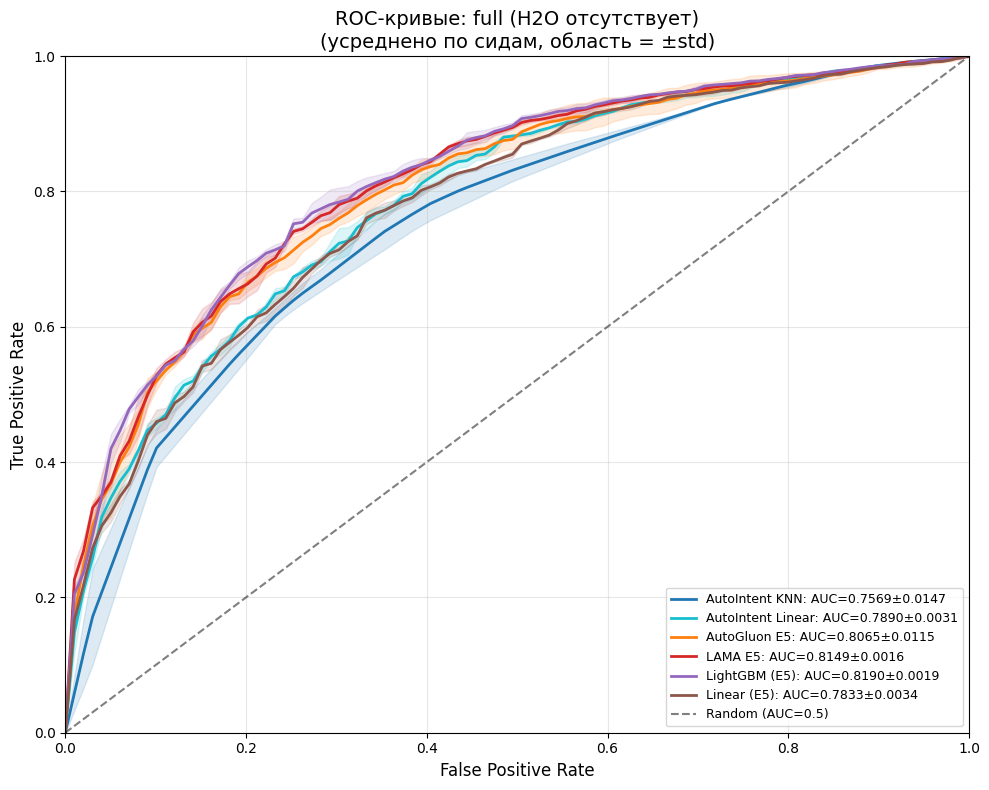

In [13]:
def compute_mean_roc(participant: str, mode: str, n_points: int = 100):
    """
    Вычисляет усреднённую ROC-кривую по сидам.
    Интерполирует TPR на общую сетку FPR для усреднения.
    Возвращает (mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc) или None.
    """
    common_fpr = np.linspace(0, 1, n_points)
    all_tpr = []
    all_auc = []
    
    for seed in SEEDS:
        scores_dict = load_all_scores(mode, seed)
        if participant not in scores_dict:
            continue
        
        scores = scores_dict[participant]
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc = roc_auc_score(y_true, scores)
        
        # Интерполяция TPR на общую сетку FPR
        interp_tpr = np.interp(common_fpr, fpr, tpr)
        interp_tpr[0] = 0.0  # ROC начинается с (0, 0)
        
        all_tpr.append(interp_tpr)
        all_auc.append(auc)
    
    if not all_tpr:
        return None
    
    mean_tpr = np.mean(all_tpr, axis=0)
    std_tpr = np.std(all_tpr, axis=0)
    mean_auc = np.mean(all_auc)
    std_auc = np.std(all_auc)
    
    return common_fpr, mean_tpr, std_tpr, mean_auc, std_auc


def plot_mean_roc_for_mode(mode: str, title_suffix: str = "", degenerate_set: set = None):
    """
    Строит УСРЕДНЁННЫЕ ROC-кривые для всех участников.
    Одна кривая на участника (mean по сидам) + область ±std.
    
    degenerate_set: set of (participant, mode) для пометки вырожденных скоров.
    """
    if degenerate_set is None:
        degenerate_set = set()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Собираем всех участников с данными для этого mode
    participants_with_data = set()
    for seed in SEEDS:
        scores_dict = load_all_scores(mode, seed)
        participants_with_data.update(scores_dict.keys())
    
    # Строим ROC для каждого участника
    for participant in sorted(participants_with_data):
        result = compute_mean_roc(participant, mode)
        if result is None:
            continue
        
        fpr, mean_tpr, std_tpr, mean_auc, std_auc = result
        color = COLORS.get(participant, "gray")
        display_name = DISPLAY_NAMES.get(participant, participant)
        
        # Проверяем, вырожденные ли скоры
        is_degenerate = (participant, mode) in degenerate_set
        
        # Средняя кривая
        if is_degenerate:
            label = f"{display_name}: AUC={mean_auc:.4f}±{std_auc:.4f} ⚠️ВЫРОЖД."
            linestyle = "--"  # пунктир для вырожденных
        else:
            label = f"{display_name}: AUC={mean_auc:.4f}±{std_auc:.4f}"
            linestyle = "-"
        
        ax.plot(fpr, mean_tpr, color=color, linewidth=2, label=label, linestyle=linestyle)
        
        # Область ±std (полупрозрачная)
        ax.fill_between(fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, 
                        color=color, alpha=0.15)
    
    # Диагональ
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random (AUC=0.5)")
    
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"ROC-кривые: {mode}{title_suffix}\n(усреднено по сидам, область = ±std)", fontsize=14)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Строим ROC для full-train
print("ROC: Full-train")
print("Примечание: H2O нет в full (только fewshot).")
fig_full = plot_mean_roc_for_mode("full", " (H2O отсутствует)", DEGENERATE_SET)
plt.show()

## 1.2 ROC: Few-shot (10, 20, 50)

ROC: Few-shot
Примечание: E5_LGBM, E5_LINEAR — только full-train, в fewshot нет.
⚠️ LAMA E5 few-shot имеет вырожденные скоры (≈const 0.5), ROC ненадёжен!



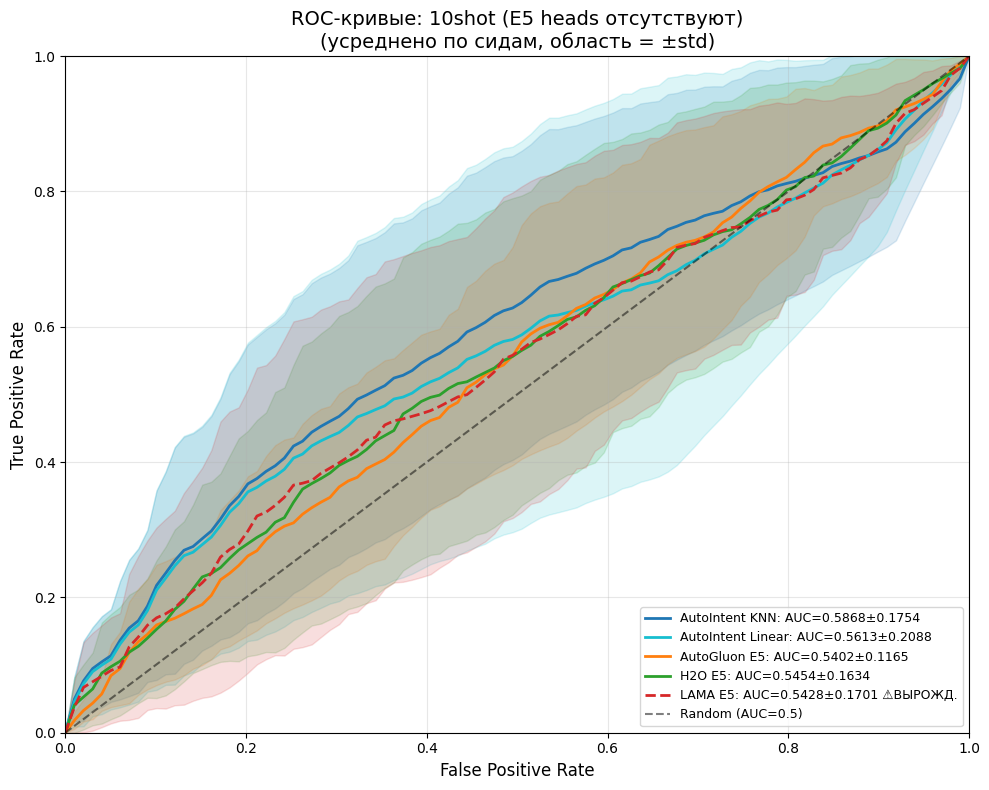

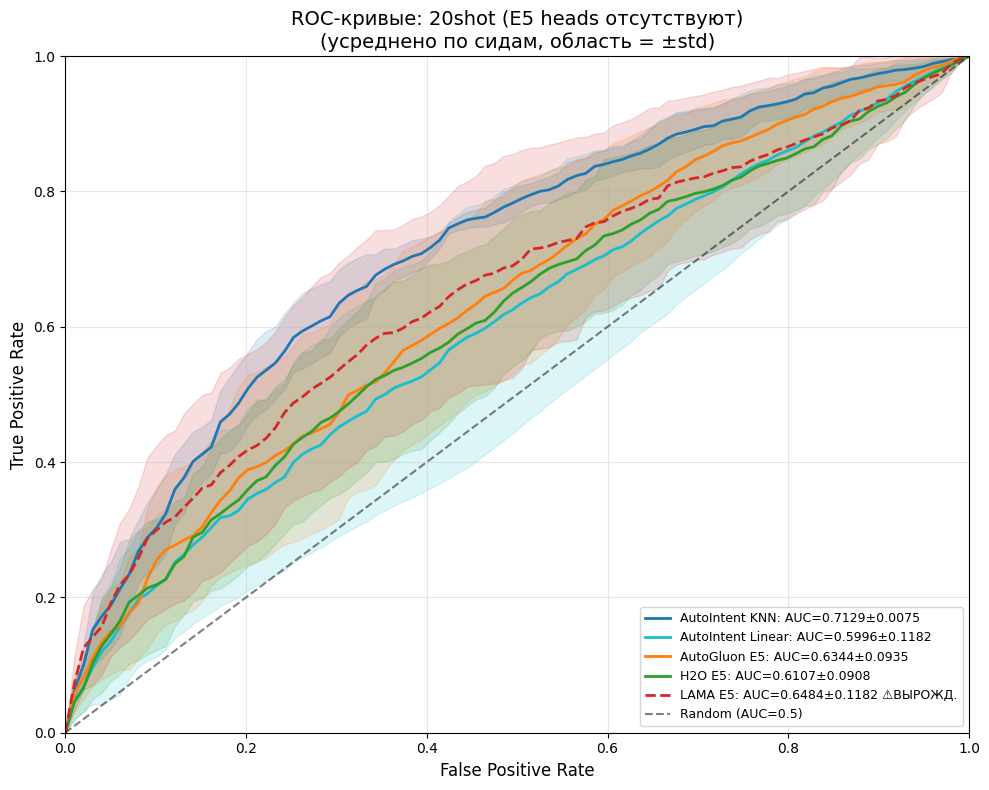

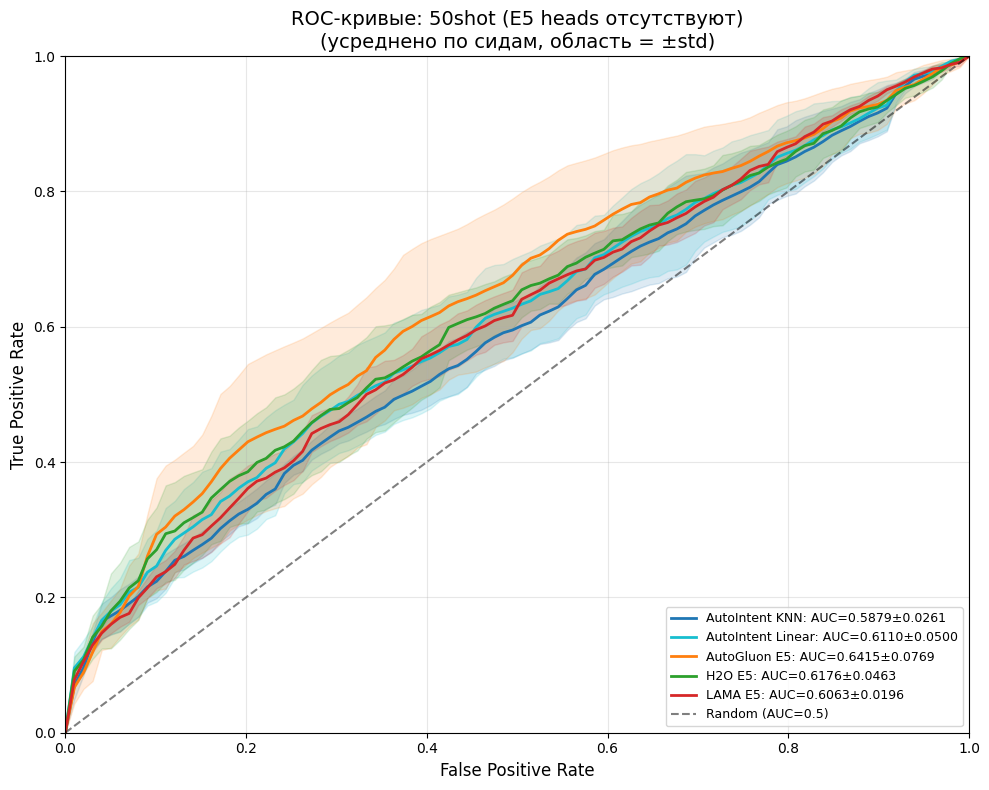

In [14]:
print("ROC: Few-shot")
print("Примечание: E5_LGBM, E5_LINEAR — только full-train, в fewshot нет.")
print("⚠️ LAMA E5 few-shot имеет вырожденные скоры (≈const 0.5), ROC ненадёжен!")
print()

for n_shots in [10, 20, 50]:
    mode = f"{n_shots}shot"
    fig = plot_mean_roc_for_mode(mode, f" (E5 heads отсутствуют)", DEGENERATE_SET)
    plt.show()

---
# ЭТАП 2: TRADE-OFF RECALL vs ORR

Строим кривую trade-off свипом порога по eval. Это НЕ подобранная рабочая точка — это визуализация всех возможных trade-off.

In [15]:
# Маски для safe/jailbreak
safe_mask = (y_true == 0)
jb_mask = (y_true == 1)

print(f"Safe примеров: {safe_mask.sum()} (для ORR = FPR на safe)")
print(f"Jailbreak примеров: {jb_mask.sum()} (для recall)")

Safe примеров: 210 (для ORR = FPR на safe)
Jailbreak примеров: 2000 (для recall)


Trade-off: Full-train


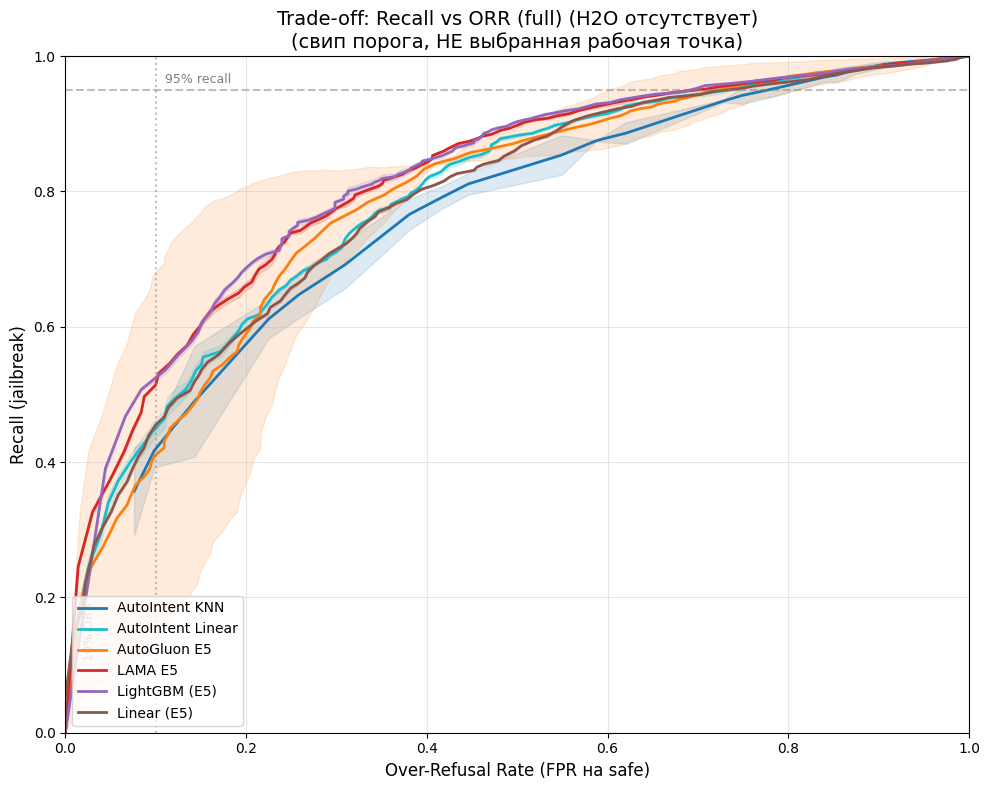

In [16]:
def compute_recall_orr_curve(scores: np.ndarray, n_thresholds: int = 100) -> tuple:
    """
    Вычисляет recall (jailbreak) и ORR (FPR на safe) для диапазона порогов.
    Возвращает (thresholds, recalls, orrs).
    """
    thresholds = np.linspace(0, 1, n_thresholds)
    recalls = []
    orrs = []
    
    for thresh in thresholds:
        preds = (scores >= thresh).astype(int)
        
        # Recall на jailbreak
        tp = ((preds == 1) & jb_mask).sum()
        fn = ((preds == 0) & jb_mask).sum()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        # ORR = FPR на safe
        fp = ((preds == 1) & safe_mask).sum()
        tn = ((preds == 0) & safe_mask).sum()
        orr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        recalls.append(recall)
        orrs.append(orr)
    
    return np.array(thresholds), np.array(recalls), np.array(orrs)


def compute_mean_recall_orr(participant: str, mode: str, n_thresholds: int = 100):
    """
    Вычисляет усреднённую кривую recall vs ORR по сидам.
    """
    all_recalls = []
    all_orrs = []
    
    for seed in SEEDS:
        scores_dict = load_all_scores(mode, seed)
        if participant not in scores_dict:
            continue
        
        scores = scores_dict[participant]
        _, recalls, orrs = compute_recall_orr_curve(scores, n_thresholds)
        all_recalls.append(recalls)
        all_orrs.append(orrs)
    
    if not all_recalls:
        return None
    
    mean_recalls = np.mean(all_recalls, axis=0)
    mean_orrs = np.mean(all_orrs, axis=0)
    std_recalls = np.std(all_recalls, axis=0)
    
    return mean_orrs, mean_recalls, std_recalls


def plot_mean_recall_vs_orr(mode: str, title_suffix: str = "", degenerate_set: set = None):
    """
    Строит усреднённую кривую recall vs ORR для всех участников.
    
    degenerate_set: set of (participant, mode) для пометки вырожденных скоров.
    """
    if degenerate_set is None:
        degenerate_set = set()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    participants_with_data = set()
    for seed in SEEDS:
        scores_dict = load_all_scores(mode, seed)
        participants_with_data.update(scores_dict.keys())
    
    for participant in sorted(participants_with_data):
        result = compute_mean_recall_orr(participant, mode)
        if result is None:
            continue
        
        mean_orrs, mean_recalls, std_recalls = result
        color = COLORS.get(participant, "gray")
        display_name = DISPLAY_NAMES.get(participant, participant)
        
        # Проверяем, вырожденные ли скоры
        is_degenerate = (participant, mode) in degenerate_set
        
        if is_degenerate:
            label = f"{display_name} ⚠️ВЫРОЖД."
            linestyle = "--"
        else:
            label = display_name
            linestyle = "-"
        
        ax.plot(mean_orrs, mean_recalls, color=color, linewidth=2, label=label, linestyle=linestyle)
        ax.fill_between(mean_orrs, mean_recalls - std_recalls, mean_recalls + std_recalls,
                        color=color, alpha=0.15)
    
    ax.set_xlabel("Over-Refusal Rate (FPR на safe)", fontsize=12)
    ax.set_ylabel("Recall (jailbreak)", fontsize=12)
    ax.set_title(f"Trade-off: Recall vs ORR ({mode}){title_suffix}\n(свип порога, НЕ выбранная рабочая точка)", fontsize=14)
    ax.legend(loc="lower left", fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    
    # Референсные линии
    ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0.10, color='gray', linestyle=':', alpha=0.5)
    ax.text(0.11, 0.96, "95% recall", fontsize=9, color='gray')
    ax.text(0.02, 0.11, "10% ORR", fontsize=9, color='gray', rotation=90)
    
    plt.tight_layout()
    return fig

# Строим для full-train
print("Trade-off: Full-train")
fig_tradeoff_full = plot_mean_recall_vs_orr("full", " (H2O отсутствует)", DEGENERATE_SET)
plt.show()

---
# ЭТАП 3: DECISION RULE НА ГРАНИЦЕ + АБСОЛЮТНЫЕ МЕТРИКИ

Цель: показать, что часть разницы в F1/ORR — это разное правило tie-breaking на границе P=0.5.

In [17]:
def compute_metrics_at_threshold(scores: np.ndarray, rule: str) -> dict:
    """
    Вычисляет метрики с заданным правилом tie-breaking.
    
    rule='A': argmax / строго >0.5 → tie идёт в safe (0)
    rule='B': >=0.5 → tie идёт в jailbreak (1)
    """
    if rule == 'A':
        preds = (scores > 0.5).astype(int)
    else:
        preds = (scores >= 0.5).astype(int)
    
    f1 = f1_score(y_true, preds, pos_label=1, zero_division=0)
    precision = precision_score(y_true, preds, pos_label=1, zero_division=0)
    recall = recall_score(y_true, preds, pos_label=1, zero_division=0)
    
    fp = ((preds == 1) & safe_mask).sum()
    tn = ((preds == 0) & safe_mask).sum()
    orr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    return {
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "ORR": orr,
        "preds": preds,
    }

def count_ties(scores: np.ndarray, threshold: float = 0.5) -> int:
    """Считает примеры ровно на пороге."""
    return int(np.sum(np.isclose(scores, threshold, atol=1e-9)))

print("Функции вычисления метрик готовы.")

Функции вычисления метрик готовы.


## 3.1 Доля примеров на границе P=0.5

In [18]:
def analyze_ties_for_mode(mode: str):
    """
    Анализирует ties (P=0.5) для всех участников в данном mode.
    """
    results = []
    
    participants_with_data = set()
    for seed in SEEDS:
        scores_dict = load_all_scores(mode, seed)
        participants_with_data.update(scores_dict.keys())
    
    for participant in sorted(participants_with_data):
        ties_by_seed = []
        for seed in SEEDS:
            scores_dict = load_all_scores(mode, seed)
            if participant not in scores_dict:
                continue
            scores = scores_dict[participant]
            n_ties = count_ties(scores)
            ties_by_seed.append(n_ties)
        
        if ties_by_seed:
            display_name = DISPLAY_NAMES.get(participant, participant)
            results.append({
                "Участник": display_name,
                "Ties_seed42": ties_by_seed[0] if len(ties_by_seed) > 0 else None,
                "Ties_seed123": ties_by_seed[1] if len(ties_by_seed) > 1 else None,
                "Ties_seed456": ties_by_seed[2] if len(ties_by_seed) > 2 else None,
                "Ties_mean": np.mean(ties_by_seed),
            })
    
    return pd.DataFrame(results)

print("ПРИМЕРЫ НА ГРАНИЦЕ P=0.5 (Full-train):")
ties_df_full = analyze_ties_for_mode("full")
display(ties_df_full)

ПРИМЕРЫ НА ГРАНИЦЕ P=0.5 (Full-train):


,Участник,Ties_seed42,Ties_seed123,Ties_seed456,Ties_mean
0,AutoIntent KNN,133,152,68,117.666667
1,AutoIntent Linear,0,0,0,0.000000
2,AutoGluon E5,0,0,0,0.000000
3,LAMA E5,0,0,0,0.000000
4,LightGBM (E5),0,0,0,0.000000
5,Linear (E5),0,0,0,0.000000


In [19]:
print("\nПРИМЕРЫ НА ГРАНИЦЕ P=0.5 (Few-shot 10):")
ties_df_10 = analyze_ties_for_mode("10shot")
display(ties_df_10)


ПРИМЕРЫ НА ГРАНИЦЕ P=0.5 (Few-shot 10):


,Участник,Ties_seed42,Ties_seed123,Ties_seed456,Ties_mean
0,AutoIntent KNN,0,0,0,0.000000
1,AutoIntent Linear,0,0,0,0.000000
2,AutoGluon E5,34,1,0,11.666667
3,H2O E5,0,0,0,0.000000
4,LAMA E5,4,1,7,4.000000


## 3.2 Абсолютные метрики при двух правилах

**Источники данных:**
- AutoIntent KNN: `runs/eval_scores_autointent_classic-light_e5large_*.jsonl`
- AutoIntent Linear: `runs/eval_scores_autointent_classic-light_e5large_qp_classify_if_this_request_is_a_ja_*.jsonl`
- AutoML E5: `results/metrics.json` → `extra.scores`
- E5_LGBM, E5_LINEAR: `results/diagnostics/nb13_eval_probas.npz`

In [20]:
def compute_metrics_both_rules(mode: str):
    """
    Вычисляет абсолютные метрики для всех участников при обоих правилах tie-breaking.
    """
    results = []
    
    participants_with_data = set()
    for seed in SEEDS:
        scores_dict = load_all_scores(mode, seed)
        participants_with_data.update(scores_dict.keys())
    
    for participant in sorted(participants_with_data):
        for rule in ['A', 'B']:
            metrics_by_seed = []
            
            for seed in SEEDS:
                scores_dict = load_all_scores(mode, seed)
                if participant not in scores_dict:
                    continue
                scores = scores_dict[participant]
                m = compute_metrics_at_threshold(scores, rule)
                metrics_by_seed.append(m)
            
            if metrics_by_seed:
                display_name = DISPLAY_NAMES.get(participant, participant)
                avg = {
                    "Участник": display_name,
                    "Правило": f"Правило {rule}",
                    "F1": np.mean([m["F1"] for m in metrics_by_seed]),
                    "Recall": np.mean([m["Recall"] for m in metrics_by_seed]),
                    "ORR": np.mean([m["ORR"] for m in metrics_by_seed]),
                    "Precision": np.mean([m["Precision"] for m in metrics_by_seed]),
                }
                results.append(avg)
    
    return pd.DataFrame(results)

print("АБСОЛЮТНЫЕ МЕТРИКИ ПРИ ПОРОГЕ 0.5 (Full-train):")
print("Правило A: >0.5 (tie → safe)")
print("Правило B: >=0.5 (tie → jailbreak)")
print()

metrics_full = compute_metrics_both_rules("full")
metrics_full_pivot = metrics_full.pivot(index="Участник", columns="Правило", values=["F1", "Recall", "ORR", "Precision"])
display(metrics_full_pivot.round(4))

АБСОЛЮТНЫЕ МЕТРИКИ ПРИ ПОРОГЕ 0.5 (Full-train):
Правило A: >0.5 (tie → safe)
Правило B: >=0.5 (tie → jailbreak)



F1              Recall                 ORR            \
Правило           Правило A Правило B Правило A Правило B Правило A Правило B   
Участник                                                                        
AutoGluon E5         0.8746    0.8746    0.8082    0.8082    0.3746    0.3746   
AutoIntent KNN       0.9083    0.9290    0.8863    0.9338    0.6206    0.7286   
AutoIntent Linear    0.8599    0.8599    0.7830    0.7830    0.3635    0.3635   
LAMA E5              0.8868    0.8868    0.8280    0.8280    0.3746    0.3746   
LightGBM (E5)        0.8885    0.8885    0.8312    0.8312    0.3794    0.3794   
Linear (E5)          0.8504    0.8504    0.7665    0.7665    0.3444    0.3444   

                  Precision            
Правило           Правило A Правило B  
Участник                               
AutoGluon E5         0.9536    0.9536  
AutoIntent KNN       0.9315    0.9243  
AutoIntent Linear    0.9535    0.9535  
LAMA E5              0.9547    0.9547  
LightGBM (E5)        0.9543    0.9543  
Linear (E5)          0.9549    0.9549

## 3.3 Таблица дельт между правилами

In [21]:
def compute_deltas(mode: str):
    """
    Вычисляет дельты между Правилом A и Правилом B.
    """
    results = []
    
    participants_with_data = set()
    for seed in SEEDS:
        scores_dict = load_all_scores(mode, seed)
        participants_with_data.update(scores_dict.keys())
    
    for participant in sorted(participants_with_data):
        n_diff_by_seed = []
        delta_f1_by_seed = []
        delta_recall_by_seed = []
        delta_orr_by_seed = []
        
        for seed in SEEDS:
            scores_dict = load_all_scores(mode, seed)
            if participant not in scores_dict:
                continue
            scores = scores_dict[participant]
            
            m_a = compute_metrics_at_threshold(scores, 'A')
            m_b = compute_metrics_at_threshold(scores, 'B')
            
            n_diff = int(np.sum(m_a["preds"] != m_b["preds"]))
            n_diff_by_seed.append(n_diff)
            delta_f1_by_seed.append(m_b["F1"] - m_a["F1"])
            delta_recall_by_seed.append(m_b["Recall"] - m_a["Recall"])
            delta_orr_by_seed.append(m_b["ORR"] - m_a["ORR"])
        
        if n_diff_by_seed:
            display_name = DISPLAY_NAMES.get(participant, participant)
            results.append({
                "Участник": display_name,
                "N_diff_mean": np.mean(n_diff_by_seed),
                "N_diff_seeds": str(n_diff_by_seed),
                "ΔF1 (B-A)": np.mean(delta_f1_by_seed),
                "ΔRecall (B-A)": np.mean(delta_recall_by_seed),
                "ΔORR (B-A)": np.mean(delta_orr_by_seed),
            })
    
    return pd.DataFrame(results)

print("ДЕЛЬТЫ: Правило B (>=0.5) минус Правило A (>0.5)")
print("N_diff = количество предсказаний, которые различаются между правилами")
print()

print("Full-train:")
deltas_full = compute_deltas("full")
display(deltas_full.round(4))

ДЕЛЬТЫ: Правило B (>=0.5) минус Правило A (>0.5)
N_diff = количество предсказаний, которые различаются между правилами

Full-train:


,Участник,N_diff_mean,N_diff_seeds,ΔF1 (B-A),ΔRecall (B-A),ΔORR (B-A)
0,AutoIntent KNN,117.6667,"[133, 152, 68]",0.0207,0.0475,0.1079
1,AutoIntent Linear,0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000
2,AutoGluon E5,0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000
3,LAMA E5,0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000
4,LightGBM (E5),0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000
5,Linear (E5),0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000


In [22]:
print("\nFew-shot (10 shots):")
deltas_10 = compute_deltas("10shot")
display(deltas_10.round(4))


Few-shot (10 shots):


,Участник,N_diff_mean,N_diff_seeds,ΔF1 (B-A),ΔRecall (B-A),ΔORR (B-A)
0,AutoIntent KNN,0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000
1,AutoIntent Linear,0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000
2,AutoGluon E5,11.3333,"[34, 0, 0]",0.0037,0.0055,0.0016
3,H2O E5,0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000
4,LAMA E5,0.0000,"[0, 0, 0]",0.0000,0.0000,0.0000


## 3.4 Итог (факты, без интерпретации)

In [23]:
print("=" * 60)
print("ИТОГ: ВЛИЯНИЕ DECISION RULE")
print("=" * 60)
print()
print("Правила, используемые в реальных реализациях:")
print("- AutoIntent KNN: argmax → tie идёт в safe (эквивалент Правила A)")
print("- AutoIntent Linear: argmax → tie идёт в safe (эквивалент Правила A)")
print("- AutoML E5 wrappers: >=0.5 → tie идёт в jailbreak (Правило B)")
print("- TF-IDF LAMA baseline: >0.5 → tie идёт в safe (Правило A)")
print()
print("Таблицы выше показывают:")
print("1. Сколько примеров попадают ровно на P=0.5 (ties)")
print("2. Абсолютные метрики при каждом правиле (не только дельты)")
print("3. Насколько выбор правила влияет на F1/Recall/ORR")
print()
print("Если N_diff=0, выбор правила не влияет (нет ties на 0.5).")
print("Если N_diff>0, репортируемые метрики зависят от правила.")
print()
print("=" * 60)
print("ПРИМЕЧАНИЕ: AutoIntent KNN vs AutoIntent Linear")
print("=" * 60)
print("- AutoIntent KNN: обычный прогон без query_prompt, оптимизация выбрала KNN scorer")
print("- AutoIntent Linear: прогон с query_prompt, который сломал KNN на eval,")
print("  и оптимизация выбрала Linear scorer (LogReg). Подробности в nb10.")

ИТОГ: ВЛИЯНИЕ DECISION RULE

Правила, используемые в реальных реализациях:
- AutoIntent KNN: argmax → tie идёт в safe (эквивалент Правила A)
- AutoIntent Linear: argmax → tie идёт в safe (эквивалент Правила A)
- AutoML E5 wrappers: >=0.5 → tie идёт в jailbreak (Правило B)
- TF-IDF LAMA baseline: >0.5 → tie идёт в safe (Правило A)

Таблицы выше показывают:
1. Сколько примеров попадают ровно на P=0.5 (ties)
2. Абсолютные метрики при каждом правиле (не только дельты)
3. Насколько выбор правила влияет на F1/Recall/ORR

Если N_diff=0, выбор правила не влияет (нет ties на 0.5).
Если N_diff>0, репортируемые метрики зависят от правила.

ПРИМЕЧАНИЕ: AutoIntent KNN vs AutoIntent Linear
- AutoIntent KNN: обычный прогон без query_prompt, оптимизация выбрала KNN scorer
- AutoIntent Linear: прогон с query_prompt, который сломал KNN на eval,
  и оптимизация выбрала Linear scorer (LogReg). Подробности в nb10.


---
# ПРИЛОЖЕНИЕ: Сводная таблица ROC-AUC

In [24]:
def build_auc_summary():
    """Строит сводную таблицу ROC-AUC для всех участников и режимов."""
    results = []
    
    for mode in MODES_ALL:
        participants_with_data = set()
        for seed in SEEDS:
            scores_dict = load_all_scores(mode, seed)
            participants_with_data.update(scores_dict.keys())
        
        for participant in sorted(participants_with_data):
            aucs = []
            for seed in SEEDS:
                scores_dict = load_all_scores(mode, seed)
                if participant in scores_dict:
                    auc = roc_auc_score(y_true, scores_dict[participant])
                    aucs.append(auc)
            
            if aucs:
                display_name = DISPLAY_NAMES.get(participant, participant)
                results.append({
                    "Участник": display_name,
                    "Режим": mode,
                    "AUC_mean": np.mean(aucs),
                    "AUC_std": np.std(aucs),
                })
    
    return pd.DataFrame(results)

auc_summary = build_auc_summary()
auc_pivot = auc_summary.pivot(index="Участник", columns="Режим", values="AUC_mean")
auc_pivot = auc_pivot[["full", "10shot", "20shot", "50shot"]]

print("СВОДНАЯ ТАБЛИЦА ROC-AUC (среднее по сидам):")
display(auc_pivot.round(4))

СВОДНАЯ ТАБЛИЦА ROC-AUC (среднее по сидам):


Режим,full,10shot,20shot,50shot
Участник,,,,
AutoGluon E5,0.8065,0.5402,0.6344,0.6415
AutoIntent KNN,0.7569,0.5868,0.7129,0.5879
AutoIntent Linear,0.7890,0.5613,0.5996,0.6110
H2O E5,NaN,0.5454,0.6107,0.6176
LAMA E5,0.8149,0.5428,0.6484,0.6063
LightGBM (E5),0.8190,NaN,NaN,NaN
Linear (E5),0.7833,NaN,NaN,NaN
